C:\Users\Aayush Kuthe\AppData\Local\Temp\ipykernel_24692\2648415725.py:13: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('Interest Rate and Economic Growth Rate.csv', parse_dates=['Date'])
C:\Users\Aayush Kuthe\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 1.8395 - mae: 0.9857 - val_loss: 0.9233 - val_mae: 0.7711 - learning_rate: 0.0010
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.5764 - mae: 0.3955 - val_loss: 0.8234 - val_mae: 0.7142 - learning_rate: 0.0010
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.4713 - mae: 0.3248 - val_loss: 0.7689 - val_mae: 0.6854 - learning_rate: 0.0010
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.3976 - mae: 0.2523 - val_loss: 0.6911 - val_mae: 0.6375 - learning_rate: 0.0010
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.3730 - mae: 0.2445 - val_loss: 0.6139 - val_mae: 0.5856 - learning_rate: 0.0010
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.3305 - mae: 0.2038 - val_loss: 0.5835 - val_mae: 0.5708 - learning_rate: 0.0010
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.3109 - mae: 0.1928 - val_loss: 0.5234 - val_mae: 0.5266 - learning_rate: 0.0010
Epoch 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Train R²: 0.9617, Test R²: 0.3849
Train RMSE: 0.2880, Test RMSE: 2.8183


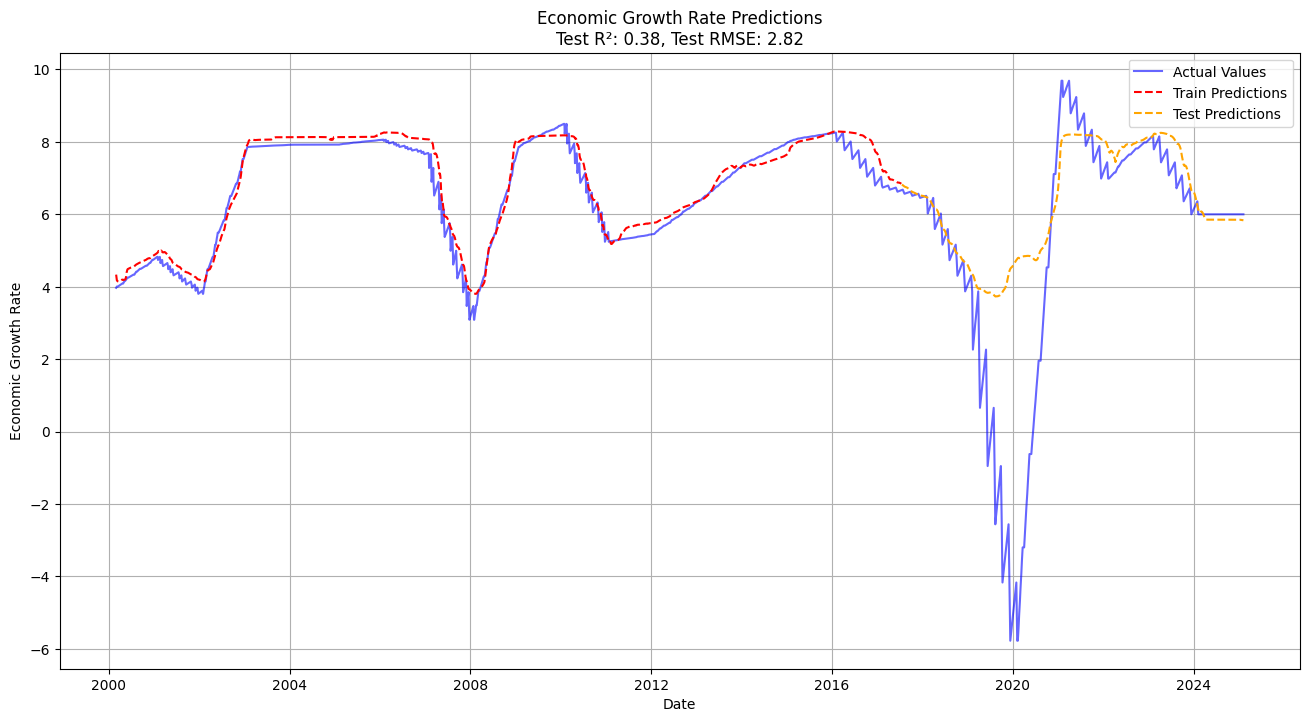

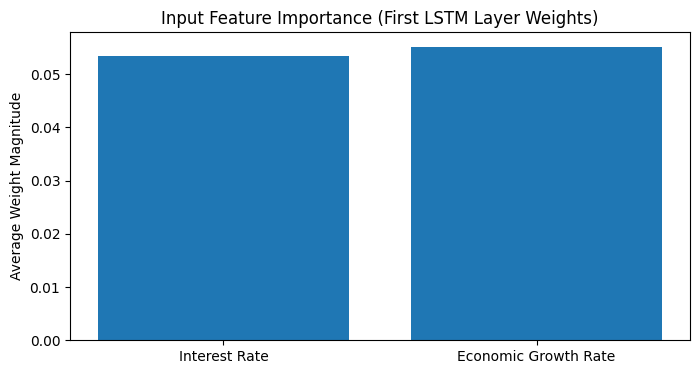

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import save_model

# Load and preprocess data
df = pd.read_csv('Interest Rate and Economic Growth Rate.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

# Feature engineering: Add moving averages
window_size = 5
df['Interest_MA'] = df['Interest Rate'].rolling(window=window_size).mean()
df['Growth_MA'] = df['Economic Growth Rate'].rolling(window=window_size).mean()
df.dropna(inplace=True)

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Interest Rate', 'Economic Growth Rate', 'Interest_MA', 'Growth_MA']])

# Create sequences with multiple features
def create_sequences(data, look_back=10):
    X, y = [], []
    for i in range(len(data)-look_back):
        X.append(data[i:(i+look_back), :2])  # Use both interest rate and growth rate
        y.append(data[i+look_back, 1])       # Predict growth rate
    return np.array(X), np.array(y)

look_back = 10  # Increased window size
X, y = create_sequences(scaled_data, look_back)

# Split into train/test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build enhanced LSTM model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(look_back, 2)),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer='l2'),
    Dense(1)
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Add callbacks
callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=10)
]

# Train model with more epochs
history = model.fit(X_train, y_train,
                    epochs=300,
                    batch_size=64,
                    validation_split=0.2,
                    callbacks=callbacks,
                    verbose=1)

# Save model
save_model(model, 'improved_economic_growth_lstm.h5')

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scaling
def inverse_scale(y, scaler, feature_pos=1):
    dummy = np.zeros((len(y), scaled_data.shape[1]))
    dummy[:, feature_pos] = y.reshape(-1)
    return scaler.inverse_transform(dummy)[:, feature_pos]

y_train_actual = inverse_scale(y_train, scaler)
y_test_actual = inverse_scale(y_test, scaler)
train_predict = inverse_scale(train_predict, scaler)
test_predict = inverse_scale(test_predict, scaler)

# Calculate metrics
train_r2 = r2_score(y_train_actual, train_predict)
test_r2 = r2_score(y_test_actual, test_predict)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f"Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")


# Enhanced visualization
total_samples = len(X)  # This matches y_train_actual + y_test_actual
start_index = look_back  # First valid index after sequence creation

# Create date range for predictions
prediction_dates = df['Date'].iloc[start_index:start_index+total_samples]

plt.figure(figsize=(16, 8))
plt.plot(prediction_dates, np.concatenate([y_train_actual, y_test_actual]), 
         label='Actual Values', color='blue', alpha=0.6)

# Plot predictions
plt.plot(prediction_dates[:len(y_train_actual)], train_predict, 
         label='Train Predictions', color='red', linestyle='--')
plt.plot(prediction_dates[len(y_train_actual):], test_predict,
         label='Test Predictions', color='orange', linestyle='--')

plt.title(f'Economic Growth Rate Predictions\nTest R²: {test_r2:.2f}, Test RMSE: {test_rmse:.2f}')
plt.ylabel('Economic Growth Rate')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

# Feature importance analysis
plt.figure(figsize=(8, 4))
plt.bar(['Interest Rate', 'Economic Growth Rate'],
        np.abs(model.layers[0].get_weights()[0]).mean(axis=1))
plt.title('Input Feature Importance (First LSTM Layer Weights)')
plt.ylabel('Average Weight Magnitude')
plt.show()